# 01 — X-Wines EDA dataset exploration

In [15]:
from __future__ import annotations

import matplotlib.pyplot as plt
import polars as pl

from vininator.data.load import (
    scan_xwines_ratings,
    scan_xwines_wines,
    xwines_info,
)

pl.Config.set_tbl_rows(20)
pl.Config.set_tbl_cols(20)

wines = scan_xwines_wines()
ratings = scan_xwines_ratings()

## 1. Schemas & dtypes

In [16]:
info = xwines_info()
print(f"variant: {info['variant']}\n")
for name in ("wines", "ratings"):
    block = info[name]
    print(f"=== {name}: {block['rows']:,} rows, {len(block['columns'])} columns ===")
    for col in block["columns"]:
        print(f"  {col:<18} {block['dtypes'][col]}")
    print()

variant: test

=== wines: 100,646 rows, 17 columns ===
  WineID             Int64
  WineName           String
  Type               String
  Elaborate          String
  Grapes             List(String)
  Harmonize          String
  ABV                Float64
  Body               String
  Acidity            String
  Code               String
  Country            String
  RegionID           Int64
  RegionName         String
  WineryID           Int64
  WineryName         String
  Website            String
  Vintages           List(Int64)

=== ratings: 21,013,536 rows, 7 columns ===
  RatingID           Int64
  UserID             Int64
  WineID             Int64
  Vintage            Int64
  Rating             Float64
  Date               Datetime(time_unit='us', time_zone=None)
  age_at_review      Int64



## 2. Completeness

In [19]:
for name in ("wines", "ratings"):
    block = info[name]
    miss = (
        pl.DataFrame(
            {
                "column": list(block["missingness"].keys()),
                "missing_pct": [round(v * 100, 2) for v in block["missingness"].values()],
            }
        ).sort("missing_pct", descending=True)
    )
    print(f"=== {name} missing columns ===")
    print(miss)
    print()

=== wines missing columns ===
shape: (17, 2)
┌────────────┬─────────────┐
│ column     ┆ missing_pct │
│ ---        ┆ ---         │
│ str        ┆ f64         │
╞════════════╪═════════════╡
│ Website    ┆ 17.75       │
│ WineID     ┆ 0.0         │
│ WineName   ┆ 0.0         │
│ Type       ┆ 0.0         │
│ Elaborate  ┆ 0.0         │
│ Grapes     ┆ 0.0         │
│ Harmonize  ┆ 0.0         │
│ ABV        ┆ 0.0         │
│ Body       ┆ 0.0         │
│ Acidity    ┆ 0.0         │
│ Code       ┆ 0.0         │
│ Country    ┆ 0.0         │
│ RegionID   ┆ 0.0         │
│ RegionName ┆ 0.0         │
│ WineryID   ┆ 0.0         │
│ WineryName ┆ 0.0         │
│ Vintages   ┆ 0.0         │
└────────────┴─────────────┘

=== ratings missing columns ===
shape: (7, 2)
┌───────────────┬─────────────┐
│ column        ┆ missing_pct │
│ ---           ┆ ---         │
│ str           ┆ f64         │
╞═══════════════╪═════════════╡
│ Vintage       ┆ 2.11        │
│ age_at_review ┆ 2.11        │
│ RatingID      ┆

## 3. Check dataset if `age_at_review` is available to calculate

In [20]:
age_stats = ratings.select(pl.col("age_at_review")).collect().to_series()
print(age_stats.describe())
n_total = len(age_stats)
n_negative = (age_stats < 0).sum()
n_over_50  = (age_stats > 50).sum()
print(f"\nratings with age < 0:   {n_negative:,} ({100*n_negative/n_total:.2f}%) - rated before bottling")
print(f"ratings with age > 50:  {n_over_50:,} ({100*n_over_50/n_total:.2f}%) - long-aged or data error")

shape: (9, 2)
┌────────────┬─────────────┐
│ statistic  ┆ value       │
│ ---        ┆ ---         │
│ str        ┆ f64         │
╞════════════╪═════════════╡
│ count      ┆ 2.0571145e7 │
│ null_count ┆ 442391.0    │
│ mean       ┆ 4.155849    │
│ std        ┆ 4.3809      │
│ min        ┆ 0.0         │
│ 25%        ┆ 2.0         │
│ 50%        ┆ 3.0         │
│ 75%        ┆ 5.0         │
│ max        ┆ 71.0        │
└────────────┴─────────────┘

ratings with age < 0:   0 (0.00%) - rated before bottling
ratings with age > 50:  12,484 (0.06%) - long-aged or data error


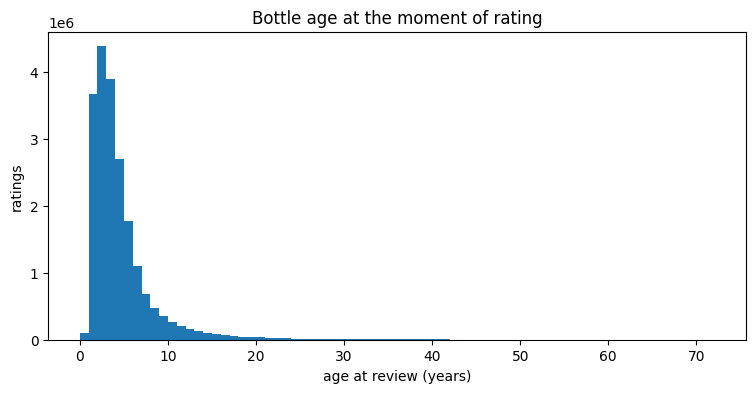

In [21]:
ages = ratings.select("age_at_review").collect().to_series().drop_nulls()
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(ages.to_numpy(), bins=range(int(ages.min()), int(ages.max()) + 2))
ax.set_xlabel("age at review (years)")
ax.set_ylabel("ratings")
ax.set_title("Bottle age at the moment of rating")
plt.show()

Date range: 2012-01-03 08:20:53 -> 2021-12-31 23:59:56


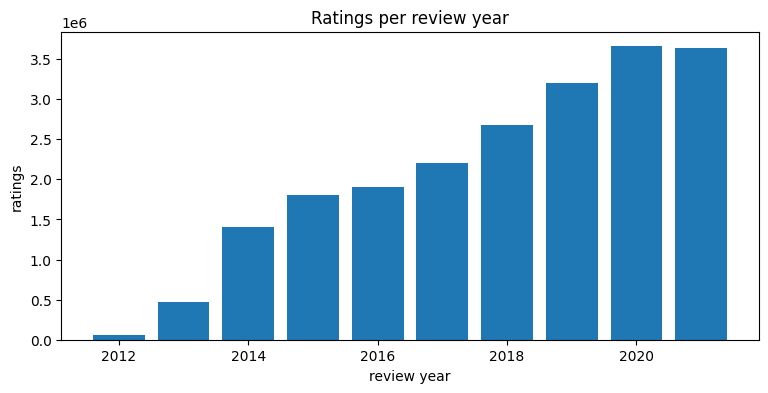

shape: (10, 2)
┌─────────────┬───────────┐
│ review_year ┆ n_ratings │
│ ---         ┆ ---       │
│ i32         ┆ u32       │
╞═════════════╪═══════════╡
│ 2012        ┆ 53699     │
│ 2013        ┆ 464462    │
│ 2014        ┆ 1403015   │
│ 2015        ┆ 1805355   │
│ 2016        ┆ 1900597   │
│ 2017        ┆ 2204047   │
│ 2018        ┆ 2682560   │
│ 2019        ┆ 3207094   │
│ 2020        ┆ 3658529   │
│ 2021        ┆ 3634178   │
└─────────────┴───────────┘


In [22]:
# Coverage of the Date column itself.
date_rng = ratings.select(
    pl.col("Date").min().alias("min"),
    pl.col("Date").max().alias("max"),
).collect().row(0)
print(f"Date range: {date_rng[0]} -> {date_rng[1]}")

per_year = (
    ratings.with_columns(pl.col("Date").dt.year().alias("review_year"))
    .group_by("review_year")
    .agg(pl.len().alias("n_ratings"))
    .sort("review_year")
    .collect()
)
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(per_year["review_year"].to_numpy(), per_year["n_ratings"].to_numpy())
ax.set_xlabel("review year")
ax.set_ylabel("ratings")
ax.set_title("Ratings per review year")
plt.show()
print(per_year)

## 4. Rating distribution

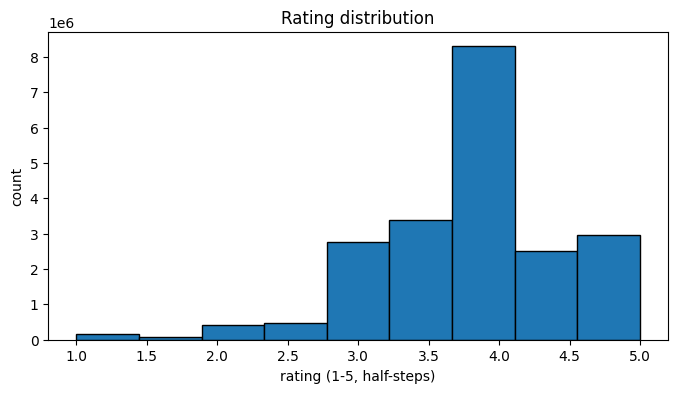

mean=3.885  median=4.000  std=0.738  n=21,013,536


In [23]:
r = ratings.select("Rating").collect().to_series()
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(r.to_numpy(), bins=9, edgecolor="black")
ax.set_xlabel("rating (1-5, half-steps)")
ax.set_ylabel("count")
ax.set_title("Rating distribution")
plt.show()
print(f"mean={r.mean():.3f}  median={r.median():.3f}  std={r.std():.3f}  n={len(r):,}")

## 5. Grape / region / country / winery cardinality

In [25]:
n_wines = wines.select(pl.len()).collect().item()
print(f"wines:        {n_wines:,}")
for col in ("Type", "Country", "RegionName", "WineryID"):
    n_unique = wines.select(pl.col(col).n_unique()).collect().item()
    print(f"  unique {col:<12} {n_unique:,}")

n_grapes = (
    wines.select(pl.col("Grapes").explode().alias("grape"))
    .drop_nulls().select(pl.col("grape").n_unique()).collect().item()
)
print(f"  unique Grapes        {n_grapes:,}")

wines:        100,646
  unique Type         6
  unique Country      62
  unique RegionName   2,160
  unique WineryID     30,510
  unique Grapes        777


In [26]:
# Top 20 regions by wine count.
(
    wines.group_by("RegionName")
    .agg(pl.len().alias("n_wines"))
    .sort("n_wines", descending=True)
    .head(20)
    .collect()
)

RegionName,n_wines
str,u32
"""Mendoza""",2404
"""Bourgogne""",2182
"""California""",1831
"""Champagne""",1794
"""Napa Valley""",1741
"""Toscana""",1592
"""Rioja""",1475
"""Veneto""",1373
"""Douro""",1298


In [27]:
# Top 20 grape varieties by wine count.
(
    wines.select(pl.col("Grapes").explode().alias("grape"))
    .drop_nulls()
    .group_by("grape")
    .agg(pl.len().alias("n_wines"))
    .sort("n_wines", descending=True)
    .head(20)
    .collect()
)

grape,n_wines
str,u32
"""Cabernet Sauvignon""",14371
"""Chardonnay""",12416
"""Merlot""",10554
"""Pinot Noir""",10474
"""Syrah/Shiraz""",10090
"""Cabernet Franc""",5354
"""Grenache""",4149
"""Sauvignon Blanc""",4084
"""Riesling""",4001


## 6. Vintage coverage on ratings

Per-rating `Vintage` is the year the wine was bottled. This is what gets joined to ERA5 in Phase 2.

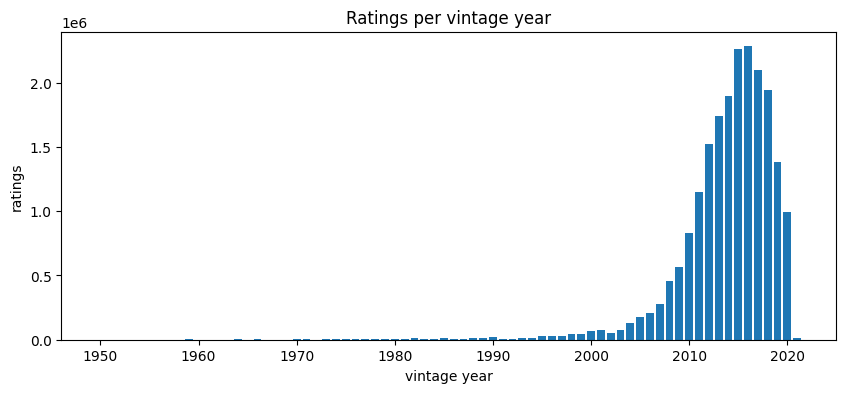

vintage range: 1950 - 2021


In [28]:
vintages_seen = (
    ratings.group_by("Vintage")
    .agg(pl.len().alias("n_ratings"))
    .sort("Vintage")
    .collect()
)
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(vintages_seen["Vintage"].to_numpy(), vintages_seen["n_ratings"].to_numpy())
ax.set_xlabel("vintage year")
ax.set_ylabel("ratings")
ax.set_title("Ratings per vintage year")
plt.show()
print(f"vintage range: {vintages_seen['Vintage'].min()} - {vintages_seen['Vintage'].max()}")

## 7. Ratings per wine

shape: (9, 2)
┌────────────┬────────────┐
│ statistic  ┆ value      │
│ ---        ┆ ---        │
│ str        ┆ f64        │
╞════════════╪════════════╡
│ count      ┆ 100646.0   │
│ null_count ┆ 0.0        │
│ mean       ┆ 208.786599 │
│ std        ┆ 588.611438 │
│ min        ┆ 5.0        │
│ 25%        ┆ 22.0       │
│ 50%        ┆ 58.0       │
│ 75%        ┆ 187.0      │
│ max        ┆ 27415.0    │
└────────────┴────────────┘


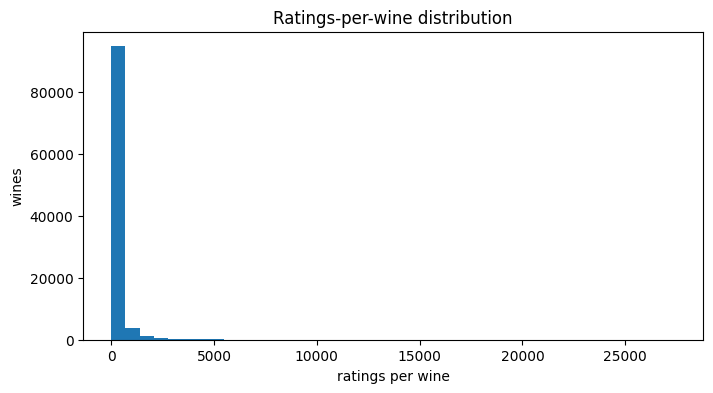

In [29]:
per_wine = (
    ratings.group_by("WineID")
    .agg(pl.len().alias("n_ratings"))
    .collect()
)
print(per_wine["n_ratings"].describe())
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(per_wine["n_ratings"].to_numpy(), bins=40)
ax.set_xlabel("ratings per wine")
ax.set_ylabel("wines")
ax.set_title("Ratings-per-wine distribution")
plt.show()

## 8. `(RegionName, Vintage)` cells - terroir-eligible subset

Joining ratings -> wines on `WineID`, then counting unique `(WineID, Vintage)` pairs per `(RegionName, Vintage)` cell. Threshold: `>= 5` distinct wines.

In [30]:
MIN_WINES = 5

joined = ratings.join(
    wines.select("WineID", "RegionName"), on="WineID", how="inner"
)
cells = (
    joined.group_by(["RegionName", "Vintage"])
    .agg(pl.col("WineID").n_unique().alias("n_wines"), pl.len().alias("n_ratings"))
    .sort("n_wines", descending=True)
    .collect()
)
eligible = cells.filter(pl.col("n_wines") >= MIN_WINES)
print(f"All (region, vintage) cells:   {len(cells):,}")
print(f"Cells with >= {MIN_WINES} unique wines: {len(eligible):,}")
print(f"Wines covered by eligible cells: {eligible['n_wines'].sum():,}")
eligible.head(30)

All (region, vintage) cells:   46,532
Cells with >= 5 unique wines: 18,546
Wines covered by eligible cells: 959,399


RegionName,Vintage,n_wines,n_ratings
str,i64,u32,u32
"""Mendoza""",2017,1885,161028
"""Mendoza""",2018,1873,134062
"""Mendoza""",2014,1835,124709
"""Mendoza""",2019,1828,83091
"""Mendoza""",2015,1810,144765
"""Mendoza""",2013,1800,122830
"""Mendoza""",2016,1756,144795
"""Bourgogne""",2015,1665,24862
"""Mendoza""",2012,1662,100720


## 9. What's actually usable - written summary

_Phase 1 deliverable, filled in against the **`full` X-Wines variant** (100,646 wines / 21,013,536 ratings, dropped in from the X-Wines Google Drive)._

- **Variant in use:** `full` (100,646 wines, 21,013,536 ratings)
- **Wines table missingness:** 0% on every column except `Website` (17.75%) — irrelevant for modeling.
- **Ratings table missingness:** 2.10% on `Vintage` and `age_at_review` (non-vintage wines, see caveats).
- **`age_at_review` summary:** count = 20,571,145; mean = 4.16y; median = 3y; std = 4.38y; p25 = 2y, p75 = 5y; min = 0y, max = 71y. 0 negative ages, 12,484 ratings (0.06%) above 50y.
- **Review-Date range:** 2012-01-03 -> 2021-12-31 (exactly 10 calendar years). Ratings volume ramps from 54k (2012) → 1.4M (2014) → 3.66M (2020), then 3.63M (2021).
- **Rating distribution:** mean = 3.89, median = 4.00, std = 0.74 (1-5 scale, half-steps).
- **Vintage coverage on ratings:** 1950 - 2021 (73 distinct vintage years).
- **Cardinalities:** **2,160** unique regions, **62** countries, **30,510** wineries, **777** grape varieties. Top countries: France (24,371 wines), Italy (19,358), USA (13,139), Spain (7,109), Portugal (4,958). Top grapes: Cabernet Sauvignon (14,371), Chardonnay (12,416), Merlot (10,554), Pinot Noir (10,474), Syrah/Shiraz (10,090). Top regions: Mendoza (2,404), Bourgogne (2,182), California (1,831), Champagne (1,794), Napa Valley (1,741).
- **Ratings per wine:** median = 58, mean = 209, min = 5, max = 27,415. All 100,646 wines have at least 5 ratings (X-Wines applies that filter upstream).
- **(RegionName, Vintage) cells with `>= 5` wines:** 18,546 eligible cells out of 46,532 total, covering 959,399 (wine, vintage) instances. That is the working set Phase 2 will geocode and pull ERA5 for.
- **Notable surprises / caveats:**
  - 2.10% of ratings are for non-vintage wines (`Vintage = "N.V."`, e.g. Champagne / Port multi-vintage blends); `age_at_review` is null for these. Phase 3 should either filter them out or treat the wine itself as the unit (no growing season exists for an N.V. blend, so they cannot join to ERA5 by vintage).
  - 12,484 ratings (0.06%) have `age_at_review > 50y`, max 71y. Plausible for old fortifieds (Port, Madeira) and library Bordeaux, but worth a spot-check in Phase 3 — the long tail can pull `age_at_review` aggregates around if not winsorized.
  - The data window (2012-2021) means `age_at_review` is correlated with vintage year: a 2010 vintage can be rated at age 2-11, but a 2020 vintage can only be rated at age 0-1. The future-vintage holdout (`Vintage >= 2019`) controls for this, but per-rating splits will not.
  - 18,546 eligible cells means **the ERA5 pull is large** — at one daily pull per `(region, vintage)`, this is ~18k × ~210 days = ~3.9M daily reanalysis records. The Phase 2 cache + resumability requirements in PROJECT.md are not optional.
  - Rating mean = 3.89 (vs. 3.5 sometimes assumed for Vivino-style data). Baselines should beat this, not 3.5.